In [1]:
%load_ext autoreload
%autoreload 2

In [2]:
import h5py, os, tqdm, glob, scipy
os.environ['XLA_PYTHON_CLIENT_MEM_FRACTION'] = '0.49'

import numpy as np
import matplotlib.pyplot as plt

import jax
import jax.numpy as jnp
import jax_cosmo as jc

import optax
from optax.losses import huber_loss
from flax import nnx
import orbax.checkpoint as ocp
import jraph

import diffrax
from diffrax import diffeqsolve, ODETerm, LeapfrogMidpoint, PIDController, SaveAt, ConstantStepSize

import jaxpm
from jaxpm import camels, plotting, hpm, nn, graph, diagnostics, objectives
from jaxpm.painting import cic_paint, cic_read, compensate_cic
from jaxpm.kernels import fftk, gradient_kernel, invlaplace_kernel, longrange_kernel, invnabla_kernel
from jaxpm.utils import power_spectrum, cross_correlation_coefficients
from jaxpm.nn import MLP, ScaleConditionedCNN
from jaxpm.objectives import ParticleLoss, FieldLoss

print(jax.default_backend())

/global/common/software/des/athomsen/flatiron/lib/python3.11/site-packages/jax_cosmo/__init__.py:2: UserWarning: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html. The pkg_resources package is slated for removal as early as 2025-11-30. Refrain from using this package or pin to Setuptools<81.
  from pkg_resources import DistributionNotFound


gpu


# configuration

In [3]:
parts_per_dim = 64
mesh_per_dim = parts_per_dim
# mesh_per_dim = 2 * parts_per_dim

# parts_per_dim = 128
# mesh_per_dim = parts_per_dim

# parts_per_dim = None
# mesh_per_dim = 256

mesh_shape = [mesh_per_dim] * 3
box_size = [float(mesh_per_dim)] * 3

# dt0 = 0.1
# dt0 = 0.02
dt0 = 0.01
# dt0 = 0.005
# dt0 = 0.001

# CAMELS

In [4]:
CODE = "SIMBA"
# CODE = "ASTRID"
# CODE = "IllustrisTNG"

train_dict = camels.load_CV_snapshots(
    "CV_0",
    mesh_per_dim,
    parts_per_dim,
    i_snapshots=None,
    CAMELS="/pscratch/sd/a/athomsen/flatiron/CAMELS",
    CODE=CODE,
)

vali_dict = camels.load_CV_snapshots(
    "CV_1",
    mesh_per_dim,
    parts_per_dim,
    i_snapshots=None,
    CAMELS="/pscratch/sd/a/athomsen/flatiron/CAMELS",
    CODE=CODE,
)

Loaded /pscratch/sd/a/athomsen/flatiron/CAMELS/h5/SIMBA/CV/CV_0/parts=64,mesh=64.h5
Loaded /pscratch/sd/a/athomsen/flatiron/CAMELS/h5/SIMBA/CV/CV_1/parts=64,mesh=64.h5


In [5]:
# for camels_dict in [train_dict, vali_dict]:
#     diagnostics.run_simulations(
#         camels_dict,
#         mesh_per_dim,
#         dt0=dt0,
#         i_plot=i_plot,
#         plot_dm=True,
#         plot_gas=False,
#     )

In [6]:
vcic_paint = jax.vmap(cic_paint, in_axes=(None,0,None))
vcic_read = jax.vmap(cic_read, in_axes=(0,0))

In [7]:
def train_step_base(model, optimizer, loss_fn_wrapper):
    loss, grads = nnx.value_and_grad(loss_fn_wrapper)(model)
    optimizer.update(grads)

    squared_sum = jax.tree_util.tree_reduce(
            lambda x, y: x + jnp.sum(y**2),
            grads,
            0.0
        )
    grad_norm = jnp.sqrt(squared_sum)

    return loss, grad_norm

def loss_base(
    loss_instance,
    y0,
    t0,
    ref_t, 
    ref_poss,
    ref_vels=None,
    ref_cls=None,
    ref_deltas=None,
    ref_Ps=None,
    gravity_model=None, 
    pressure_model=None, 
    species="gas",
):
    # integrate
    res = solve_ode(y0, t0, ref_t, gravity_model, pressure_model)
    if species == "dm":
        res_poss, res_vels = res[0], res[1]
    elif species == "gas":
        res_poss, res_vels = res[2], res[3]
    else:
        raise NotImplementedError

    # for pressure loss
    rhos_res = vcic_paint(jnp.zeros(mesh_shape), res_poss, 1)
    res_rhos = vcic_read(rhos_res, res_poss)
    
    kvec = fftk(mesh_shape)
    rhos_res_k = jnp.fft.rfftn(rhos_res, axes=(1,2,3))
    fscalar_res = jnp.fft.irfftn(rhos_res_k * invnabla_kernel(kvec), axes=(1,2,3))
    res_fscalar = vcic_read(fscalar_res, res_poss)
    
    res_inputs = [
        jnp.tile(ref_t[:,jnp.newaxis], res_rhos.shape[1]),
        jnp.log10(res_rhos + 1e-8),
        jnp.arcsinh(res_fscalar),
    ]
    res_inputs = jnp.stack(res_inputs, axis=-1)
    
    res_preds = pressure_model(res_inputs)
    res_Ps = 10 ** jnp.squeeze(res_preds)

    return loss_instance(
        res_poss,
        res_vels,
        ref_poss,
        ref_vels,
        ref_cls,
        ref_deltas,
        res_Ps,
        ref_Ps,
    )

@nnx.jit(static_argnames=("loss_instance", "model_to_train"))
def train_step(
    loss_instance,
    optimizer,
    y0,
    t0,
    ref_t, 
    ref_poss, 
    ref_vels=None,
    ref_cls=None,
    ref_deltas=None,
    ref_Ps=None,
    gravity_model=None,
    pressure_model=None,
    # static
    model_to_train="pressure",
):
    """dynamic snapshot range as passed"""

    if model_to_train == "pressure":
        def loss_fn_wrapper(model):
            return loss_base(
                loss_instance,
                y0, 
                t0,
                ref_t, 
                ref_poss, 
                ref_vels,
                ref_cls, 
                ref_deltas,
                ref_Ps,
                gravity_model=gravity_model, 
                pressure_model=model, 
                species="gas",
            )

        return train_step_base(pressure_model, optimizer, loss_fn_wrapper)

    elif model_to_train == "gravity":
        def loss_fn_wrapper(model):
            return loss_base(
                loss_instance,
                y0, 
                t0,
                ref_t, 
                ref_poss, 
                ref_vels,
                ref_cls, 
                ref_deltas,
                gravity_model=model, 
                pressure_model=pressure_model, 
                species="dm",
            )

        return train_step_base(gravity_model, optimizer, loss_fn_wrapper)
    

In [8]:
scales = train_dict["scales"]
print(np.diff(scales))
# assert np.all(np.diff(scales) > dt0)

# edges = graph.get_edges(train_dict["gas_poss"], scales, k=4)

def solve_ode(y0, t0, ts, gravity_model, pressure_model, training=True):
    ode = ODETerm(
        hpm.get_hpm_network_ode_fn(
            mesh_per_dim, 
            cosmo, 
            gravity_model=gravity_model, 
            pressure_model=pressure_model, 
            training=training,
            # precomputed_edges=edges,
        )
    )

    res = diffeqsolve(
            terms=ode,
            solver=LeapfrogMidpoint(),
            t0=t0,
            t1=ts[-1],
            dt0=dt0,
            y0=y0,
            saveat=SaveAt(ts=ts),
            max_steps=1000,
            stepsize_controller=ConstantStepSize(),
        )
    res = res.ys

    return res


[0.02380952 0.03333333 0.02222222 0.02777778 0.01224106 0.01284044
 0.01346916 0.01412867 0.01482047 0.01554614 0.01630734 0.01710582
 0.0179434  0.01882198 0.01974359 0.02071031 0.02172438 0.0227881
 0.0239039  0.02507434 0.02630208 0.02758995 0.02894087 0.03035793
 0.03184439 0.03340362 0.03503921 0.03675488 0.03855455 0.04044235
 0.04242258 0.04449977 0.04667867]


# loss

### CAMELS ground truth

In [9]:
# general
cosmo = train_dict["cosmo"]
scales = train_dict["scales"]

# particles
dm_poss = train_dict["dm_poss"]
dm_vels = train_dict["dm_vels"]

gas_poss = train_dict["gas_poss"]
gas_vels = train_dict["gas_vels"]

# fields
dm_mass = cosmo.Omega_c / (cosmo.Omega_b + cosmo.Omega_c)
gas_mass = 1 - dm_mass

rhos_dm = vcic_paint(jnp.zeros(mesh_shape), dm_poss, dm_mass)
deltas_dm = rhos_dm/rhos_dm.mean() - 1

rhos_gas = vcic_paint(jnp.zeros(mesh_shape), gas_poss, gas_mass)
deltas_gas = rhos_gas/rhos_gas.mean() - 1

# power spectrum
_, cls_dm = objectives.vpower_spectrum(deltas_dm)
_, cls_gas = objectives.vpower_spectrum(deltas_gas)

# pressure
gas_Ps = train_dict["gas_Ps"]

# gravity correction

In [10]:
i_plot = range(0, 32+8, 8)

In [11]:
gravity_model = nn.NeuralSplineFourierFilterNNX(n_knots=8, d_latent=16, rngs=nnx.Rngs(0))
gravity_loss = ParticleLoss(mesh_per_dim, w_pos=1.0, w_cls=0.1)

In [12]:
# see https://flax.readthedocs.io/en/latest/guides/checkpointing.html
checkpoint_file = os.path.join(os.getcwd(), f"checkpoints/gravity_fourier_spline_parts={parts_per_dim},mesh={mesh_per_dim},dt={dt0}.jx")
checkpointer = ocp.StandardCheckpointer()

In [13]:
try:
    abstract_model = nnx.eval_shape(lambda: gravity_model)
    graphdef, abstract_params = nnx.split(abstract_model)
    
    params = checkpointer.restore(checkpoint_file, abstract_params)
    gravity_model = nnx.merge(graphdef, params)
    print(f"successfully restored model from {checkpoint_file}")
except:
    print("failed to load model")

successfully restored model from /global/u2/a/athomsen/flatiron/JaxPM/dev/hpm/sims/checkpoints/gravity_fourier_spline_parts=64,mesh=64,dt=0.01.jx


/global/common/software/des/athomsen/flatiron/lib/python3.11/site-packages/orbax/checkpoint/_src/serialization/type_handlers.py:1269: UserWarning: Sharding info not provided when restoring. Populating sharding info from sharding file. Please note restoration time will be slightly increased due to reading from file. Note also that this option is unsafe when restoring on a different topology than the checkpoint was saved with.
  warnings.warn(


## training

In [14]:
total_steps = 300
learning_rate = 1e-3
# learning_rate = optax.cosine_decay_schedule(
#     init_value=1e-3, 
#     decay_steps=total_steps, 
#     alpha=0.1
# )
clip_norm = 1

gravity_optimizer = nnx.ModelAndOptimizer(
    gravity_model,
    optax.chain(
        optax.clip_by_global_norm(clip_norm),
        optax.adam(learning_rate)
    )
)

losses = []
grad_norms = []

In [15]:
# # evaluating the loss for all snapshots is computationally feasible
# for i in (pbar := tqdm.tqdm(range(total_steps))):
#     i0 = 0
#     y0 = (dm_poss[i0], dm_vels[i0], gas_poss[i0], gas_vels[i0])
#     t0 = scales[i0]
    
#     loss, grad_norm = train_step(
#         gravity_loss,
#         gravity_optimizer, 
#         y0, 
#         t0,
#         scales,
#         ref_poss=dm_poss, 
#         ref_cls=cls_dm,
#         ref_deltas=deltas_dm,
#         gravity_model=gravity_model,
#         pressure_model=None,
#         model_to_train="gravity",
#     )

#     losses.append(loss)
#     pbar.set_description(f"Loss: {loss:.4f}")

# fig, ax = plt.subplots()
# ax.plot(losses)
# ax.set(yscale="log")

In [16]:
# _, params = nnx.split(gravity_model)
# checkpointer.save(checkpoint_file, params, force=True)

In [17]:
# for camels_dict in [train_dict, vali_dict]:
#     diagnostics.run_simulations(
#         camels_dict,
#         mesh_per_dim,
#         gravity_model=gravity_model, 
#         dt0=dt0,
#         i_plot=i_plot,
#         plot_dm=True,
#         plot_gas=False,
#     )

# pressure correction

### MLP

In [109]:
pressure_model = MLP(
    d_in=3,
    # d_in=5,
    d_out=1, 
    d_hidden=64, 
    n_hidden=4, 
    dropout_rate=0.0,
    rngs=nnx.Rngs(0),
    norm_type="layer",
    activation=jax.nn.swish,
)

# pressure_loss = ParticleLoss(
#     mesh_per_dim,
#     w_pos=1.0,
#     w_vel=0.01,
#     w_cls=0.1,
#     # w_cross=0.0,
#     w_snapshot=0.0,
#     w_P=0.1,
#     cutoff_quantile=0.95,
#     huber=True,
# )

pressure_loss = ParticleLoss(
    mesh_per_dim,
    w_pos=0.0,
    w_vel=0.0,
    w_cls=0.0,
    w_cross=0.0,
    w_snapshot=0.0,
    w_P=1.0,
    cutoff_quantile=0.95,
    huber=True,
)

# pressure_loss = FieldLoss(
#     mesh_per_dim,
#     w_field=1.0,
#     w_cls=0.0,
#     w_cross=0.0,
#     w_snapshot=0.0,
#     # use_arcsinh=True,
# )

# learning_rate = 1e-3
learning_rate = 1e-4
# learning_rate = 1e-5

### CNN

In [110]:
# pressure_model = ScaleConditionedCNN(
#     d_in=4, 
#     d_out=1,
#     d_hidden=64,
#     n_hidden=4,
#     kernel_size=(3, 3, 3),
#     rngs=nnx.Rngs(0),
#     norm_type="layer",
#     activation=jax.nn.swish,
#     use_residual=True,
# )


# # pressure_loss = FieldLoss(
# #     mesh_per_dim,
# #     w_field=1.0,
# #     w_cls=0.1,
# #     w_cross=0.0,
# #     w_snapshot=0.0,
# #     # use_arcsinh=True,
# # )

# pressure_loss = ParticleLoss(
#     mesh_per_dim,
#     w_pos=1.0,
#     w_vel=0.01,
#     # w_cls=0.1,
#     w_cls=0.0,
#     w_cross=0.0,
#     w_snapshot=0.0,
#     cutoff_quantile=0.95,
#     huber=True,
# )

# # learning_rate = 1e-4
# learning_rate = 1e-5
# # learning_rate = 1e-6

## training

In [111]:
def train_step_wrapper(i0=0, i_loss=None):
    y0 = (dm_poss[i0], dm_vels[i0], gas_poss[i0], gas_vels[i0])
    t0 = scales[i0]
    
    if all_steps := (i_loss is None):
        i_loss = np.arange(0, len(scales))

    loss, grad_norm = train_step(
        pressure_loss,
        pressure_optimizer, 
        y0, 
        t0,
        ref_t=scales[i_loss], 
        ref_poss=gas_poss[i_loss], 
        ref_vels=gas_vels[i_loss],
        ref_cls=cls_gas[i_loss],
        ref_deltas=deltas_gas[i_loss],
        ref_Ps=gas_Ps[i_loss],
        pressure_model=pressure_model,
        gravity_model=gravity_model,
        model_to_train="pressure",
    )

    losses.append(float(loss))
    grad_norms.append(float(grad_norm))
    pbar.set_description(f"[{i_loss[0]}, {i_loss[-1]}], Loss: {loss:.4e}, Grad norm: {grad_norm:.4e}")
    

def plot_training(losses, grad_norms):
    fig, ax = plt.subplots(figsize=(6,10), nrows=2, sharex=True)
    ax[0].plot(losses)
    ax[0].set(yscale="log", title="loss")
    
    ax[1].plot(grad_norms)
    ax[1].set(yscale="log", title="norm(grad)")
    

In [112]:
total_steps = 100

# learning_rate = 1e-3
# learning_rate = 1e-4
# learning_rate = 5e-4
# learning_rate = 1e-5
# learning_rate = optax.cosine_decay_schedule(
#     init_value=1e-4, 
#     decay_steps=total_steps, 
#     alpha=0.1
# )
# learning_rate = optax.warmup_cosine_decay_schedule(
#     init_value=1e-4,
#     peak_value=1e-3,
#     end_value=1e-5,
#     warmup_steps=total_steps//5,
#     decay_steps=total_steps - total_steps//5, 
# )
clip_norm = 1

pressure_optimizer = nnx.ModelAndOptimizer(
    pressure_model,
    optax.chain(
        optax.clip_by_global_norm(clip_norm),
        optax.adam(learning_rate)
        # optax.ema(decay=0.999),
        # optax.adamw(learning_rate, b1=0.95, b2= 0.9999, eps=1e-5)
        # optax.adamw(learning_rate, eps=1e-5)
    )
)

losses = []
grad_norms = []

In [113]:
i0 = 0
i_loss = np.arange(-4, 0, dtype=int)

# i0 = -4
# i_loss = np.arange(i0, 0, dtype=int)

# i0 = -16
# i_loss = np.arange(i0, 0, dtype=int)


# i0 = 0
# i_loss = np.arange(0, 16, dtype=int)

# i0 = 20
# i_loss = np.arange(20, 24, dtype=int)

# i0 = -4
# i_loss = np.arange(i0, 0, dtype=int)


# i_loss = np.arange(-4, 0, dtype=int)
# i_loss = np.arange(-8, 0, dtype=int)
# i_loss = np.arange(0, 8, dtype=int)

## fixed snapshots

### all

[0, 33], Loss: 1.3238e+00, Grad norm: 2.6865e+00: 100%|██████████| 100/100 [02:20<00:00,  1.41s/it]


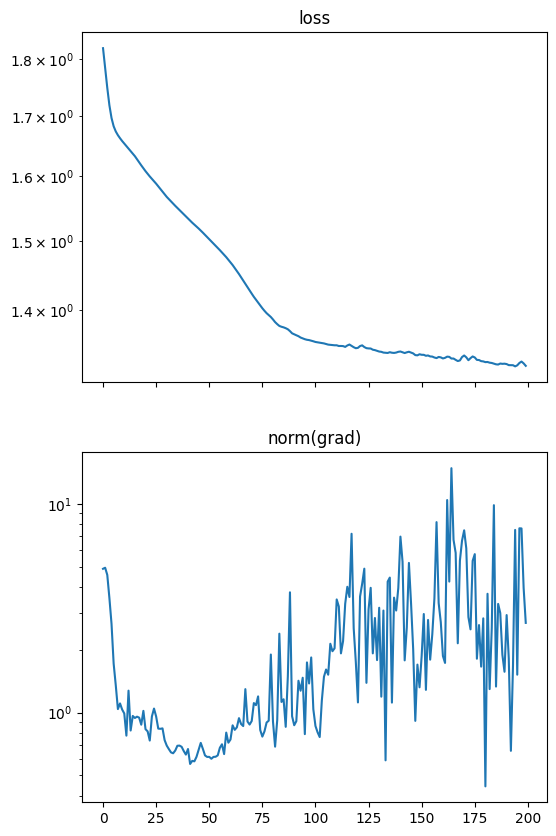

In [115]:
for i in (pbar := tqdm.tqdm(range(total_steps))):
    train_step_wrapper(i0=0)
plot_training(losses, grad_norms)

### subset

In [99]:
# for i in (pbar := tqdm.tqdm(range(total_steps))):
#     train_step_wrapper(i0=i0, i_loss=i_loss)
# plot_training(losses, grad_norms)

In [78]:
# dt0 = 0.01 -> 4.3935e-02
# dt0 = 0.02 -> 4.3427e-02
# dt0 = 0.005 -> 4.4195e-02

### curriculum

In [79]:
# i0 = 0
# i_step = 4

# # for i1 in range(i0+i_step, 32 + i_step, i_step):
# for i1 in range(i0+i_step, 16 + i_step, i_step):
#     i_loss = np.arange(i0, i1)
#     print(i_loss)
    
#     for j in (pbar := tqdm.tqdm(range(total_steps))):
#         train_step_wrapper(i0=i0, i_loss=i_loss)
        
# plot_training(losses, grad_norms)

In [80]:
# i0 = 0
# i_step = 4

# # for i1 in range(i0+i_step, 32 + i_step, i_step):
# for i1 in range(i0+i_step, 16 + i_step, i_step):
#     i_loss = np.arange(i0, i0+4)
#     print(i_loss)
    
#     for j in (pbar := tqdm.tqdm(range(total_steps))):
#         train_step_wrapper(i0=i0, i_loss=i_loss)
        
# plot_training(losses, grad_norms)

## random snapshots

### spaced

In [81]:
# i_base = np.arange(0, 32, 4)
# i_delta = 6

# for i in (pbar := tqdm.tqdm(range(total_steps))):
#     i_shift = np.random.randint(0, i_delta)
#     i_step = i_base + i_shift

#     train_step_wrapper(i_step)
# plot_training(losses, grad_norms)

### continuous

In [82]:
# i_delta = 8

# for i in (pbar := tqdm.tqdm(range(total_steps))):
#     i_rand = np.random.randint(0, len(scales) - i_delta)
#     i_step = np.arange(i_rand, i_rand + i_delta)
    
#     train_step_wrapper(i_step)
# plot_training(losses, grad_norms)

### checkpointing

In [83]:
# # see https://flax.readthedocs.io/en/latest/guides/checkpointing.html
# # checkpoint_file = os.path.join(os.getcwd(), "checkpoints/mlp_sim_v1_late_time.jx")
# # checkpoint_file = os.path.join(os.getcwd(), "checkpoints/mlp_sim_v2.jx")
# # checkpoint_file = os.path.join(os.getcwd(), "checkpoints/mlp_sim_illustris_v1.jx")
# # checkpoint_file = os.path.join(os.getcwd(), "checkpoints/mlp_pos_only_last_8.jx")
# checkpoint_file = os.path.join(os.getcwd(), "checkpoints/mlp_cls_0_to_last_4.jx")
# checkpointer = ocp.StandardCheckpointer()
# print(os.getcwd())

In [84]:
# _, params = nnx.split(pressure_model)
# checkpointer.save(checkpoint_file, params, force=True)

In [85]:
# abstract_model = nnx.eval_shape(lambda: model)
# graphdef, abstract_params = nnx.split(abstract_model)

# params = checkpointer.restore(checkpoint_file, abstract_params)
# model = nnx.merge(graphdef, params)

# run the simulation

dark matter and gas
Inferred pressure_model architecture None
dark matter and gas
Inferred pressure_model architecture None
dark matter and gas
Inferred pressure_model architecture None
dark matter and gas
Inferred pressure_model architecture mlp
Using learned correction to the gravitational potential
Using learned pressure force
No latent variable
dark matter and gas
Inferred pressure_model architecture mlp
Using learned correction to the gravitational potential
Using learned pressure force
No latent variable
dark matter and gas
Inferred pressure_model architecture mlp
Using learned correction to the gravitational potential
Using learned pressure force
No latent variable


100%|██████████| 4/4 [00:10<00:00,  2.66s/it]


dark matter and gas
Inferred pressure_model architecture None
dark matter and gas
Inferred pressure_model architecture None
dark matter and gas
Inferred pressure_model architecture None
dark matter and gas
Inferred pressure_model architecture mlp
Using learned correction to the gravitational potential
Using learned pressure force
No latent variable
dark matter and gas
Inferred pressure_model architecture mlp
Using learned correction to the gravitational potential
Using learned pressure force
No latent variable
dark matter and gas
Inferred pressure_model architecture mlp
Using learned correction to the gravitational potential
Using learned pressure force
No latent variable


100%|██████████| 4/4 [00:10<00:00,  2.57s/it]


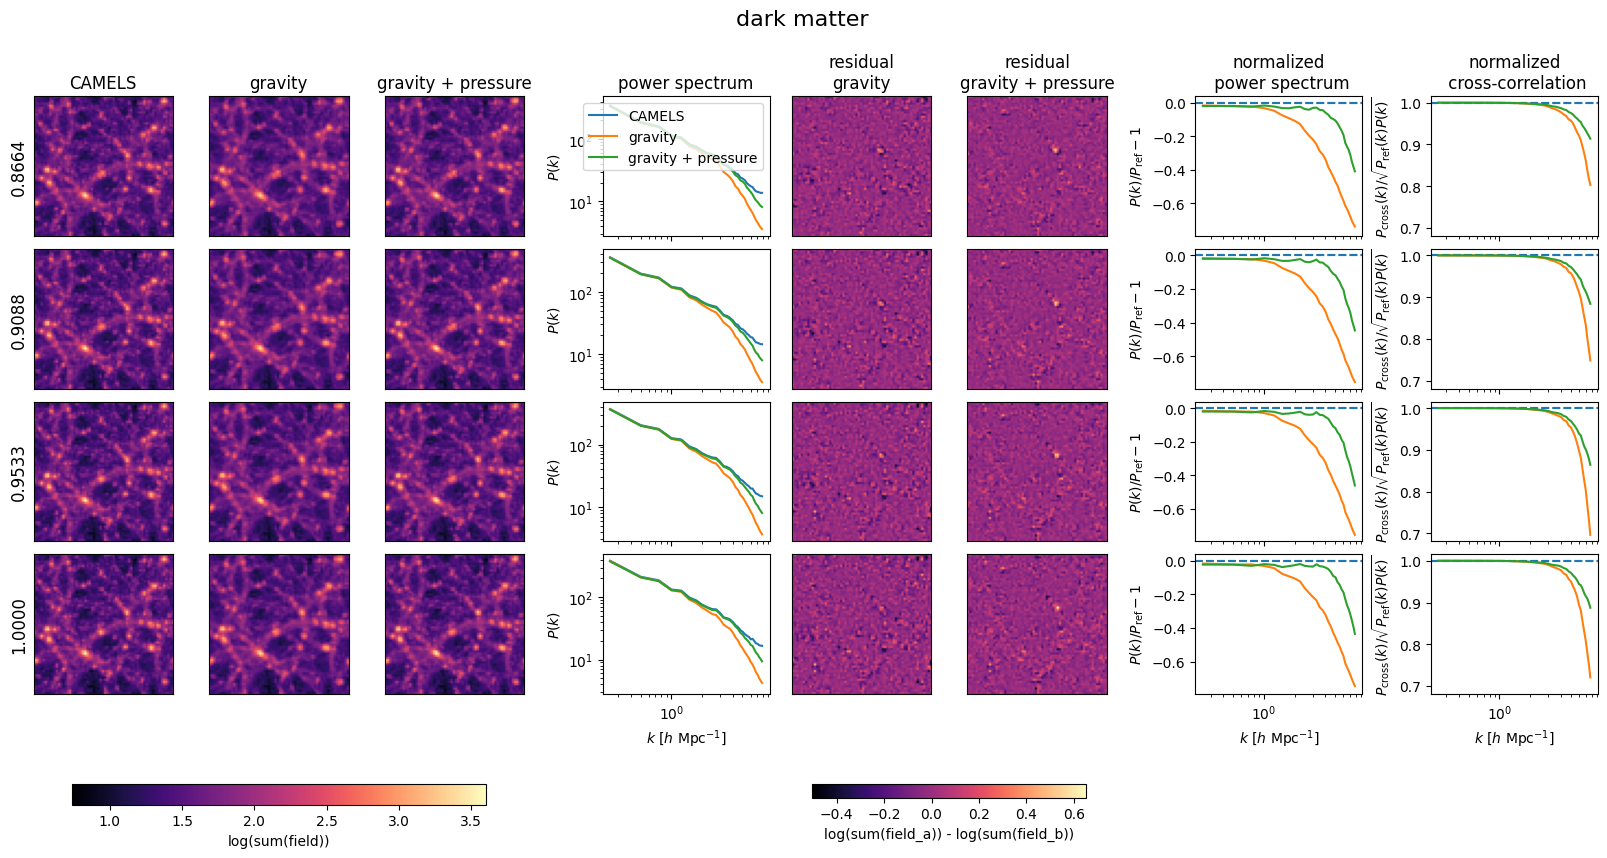

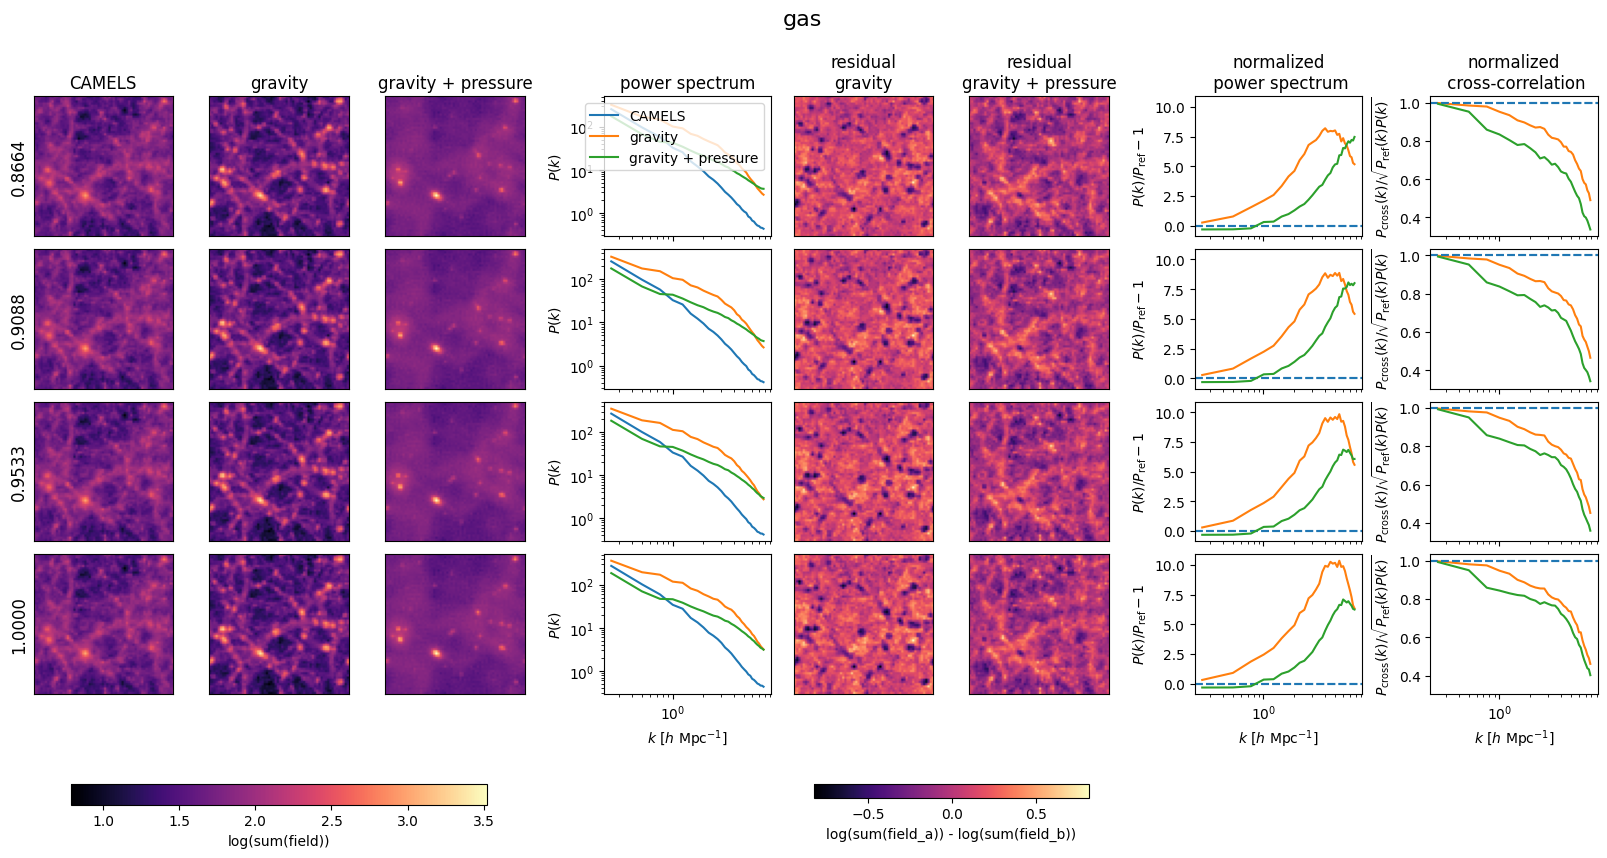

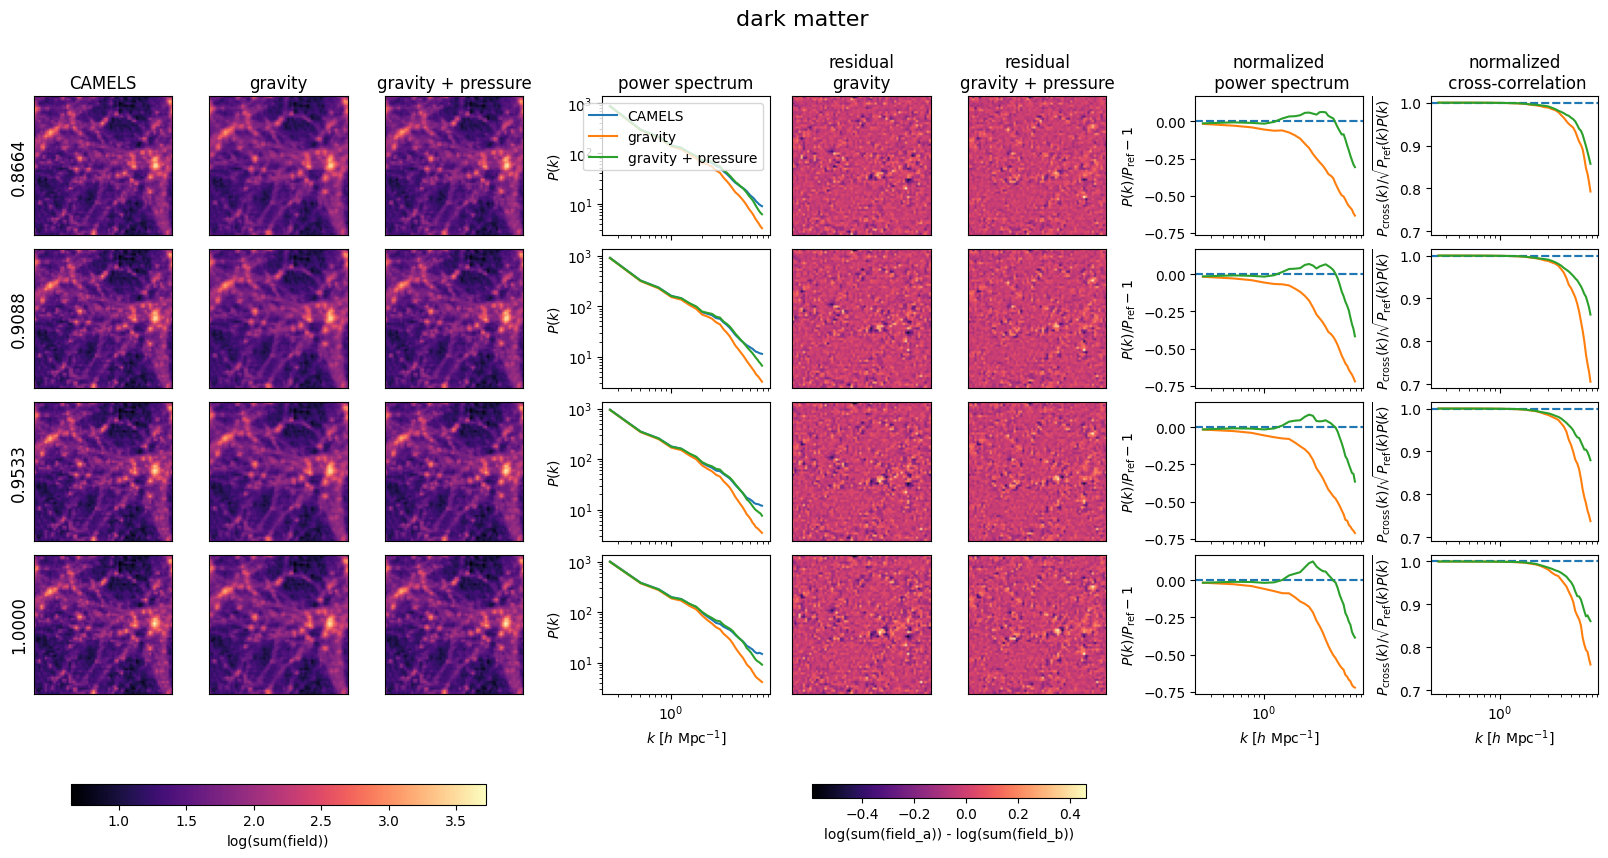

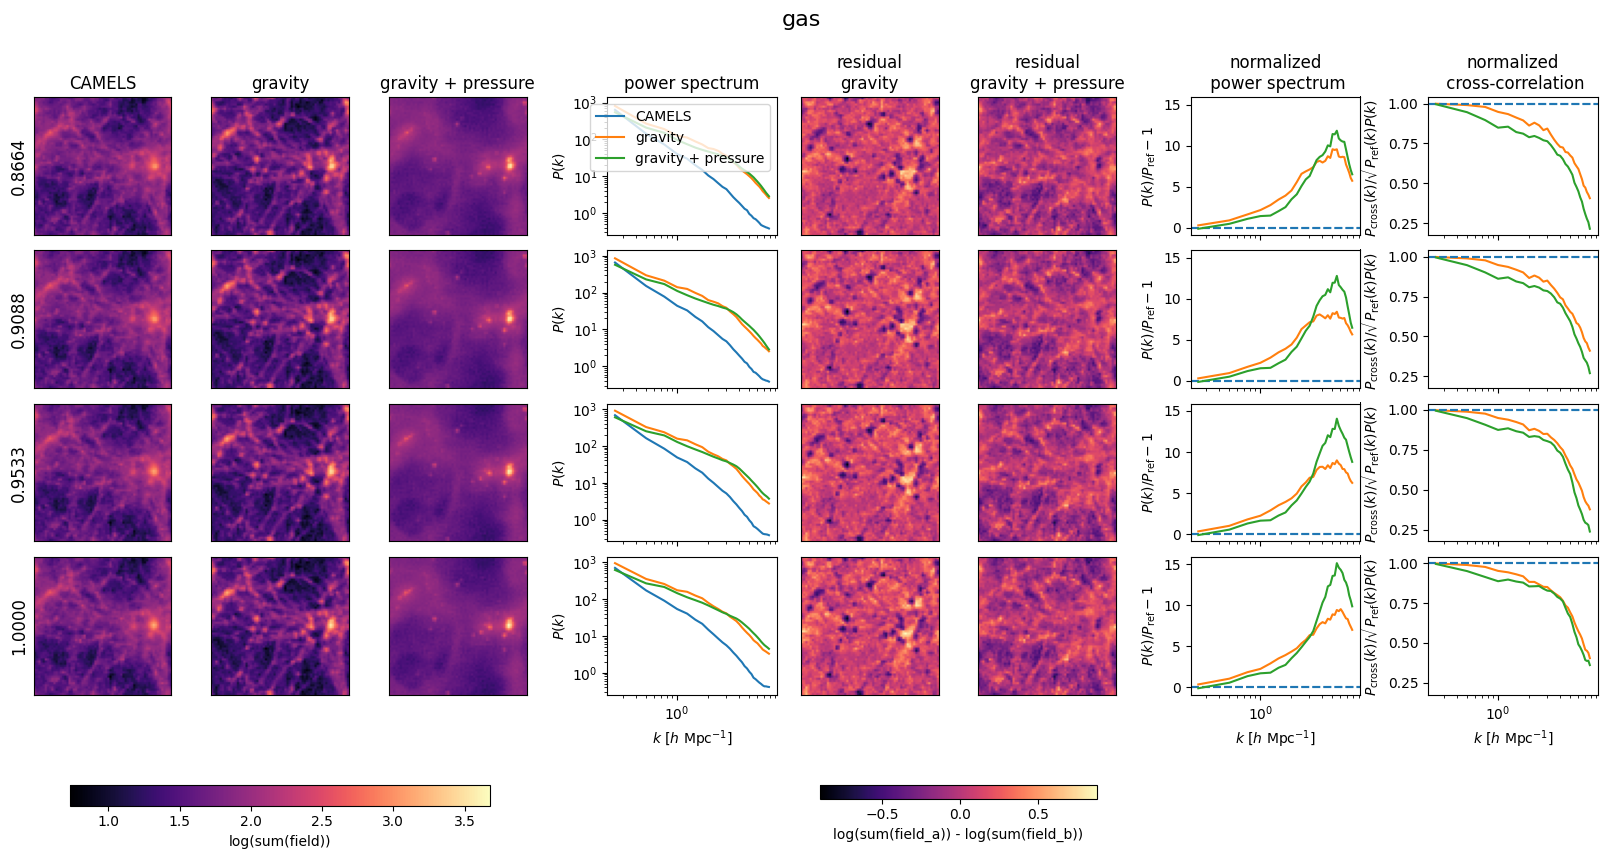

In [116]:
for camels_dict in [train_dict, vali_dict]:
    diagnostics.run_simulations(
        camels_dict,
        mesh_per_dim,
        gravity_model=gravity_model,
        pressure_model=pressure_model, 
        i_init=i0,
        # i_plot=np.arange(1, 34, 8),
        # i_plot=np.arange(0, 20, 4),
        i_plot=i_loss,
        # i_plot=i_loss[::2],
        # i_plot=i_loss[::i_step],
        # i_init=i_plot[0],
        # i_plot=i_plot,
        dt0=dt0,
        plot_dm=True,
        plot_gas=True,
    )

# debug

In [117]:
y0 = (dm_poss[i0], dm_vels[i0], gas_poss[i0], gas_vels[i0])
t0 = scales[i0]
ts = scales[i_loss]

og_res = solve_ode(y0, t0, ts, None, None)
og_dm_poss, og_dm_vels, og_gas_poss, og_gas_vels = og_res

nn_res = solve_ode(y0, t0, ts, gravity_model, pressure_model)
nn_dm_poss, nn_dm_vels, nn_gas_poss, nn_gas_vels = nn_res

dark matter and gas
Inferred pressure_model architecture None
dark matter and gas
Inferred pressure_model architecture None
dark matter and gas
Inferred pressure_model architecture None
dark matter and gas
Inferred pressure_model architecture mlp
Using learned correction to the gravitational potential
Using learned pressure force
No latent variable
dark matter and gas
Inferred pressure_model architecture mlp
Using learned correction to the gravitational potential
Using learned pressure force
No latent variable
dark matter and gas
Inferred pressure_model architecture mlp
Using learned correction to the gravitational potential
Using learned pressure force
No latent variable


In [118]:
# pressure_loss(
#     nn_gas_poss,
#     nn_gas_vels,
#     gas_poss[i_loss],
#     gas_vels[i_loss],
#     cls_gas[i_loss],
#     deltas_gas[i_loss],
#     debug=True,
# )

In [119]:
res_poss = nn_gas_poss
res_vels = nn_gas_vels
ref_t = ts

# for pressure loss
rhos_res = vcic_paint(jnp.zeros(mesh_shape), res_poss, 1)
res_rhos = vcic_read(rhos_res, res_poss)

kvec = fftk(mesh_shape)
rhos_res_k = jnp.fft.rfftn(rhos_res, axes=(1,2,3))
fscalar_res = jnp.fft.irfftn(rhos_res_k * invnabla_kernel(kvec), axes=(1,2,3))
res_fscalar = vcic_read(fscalar_res, res_poss)

res_inputs = [
    jnp.tile(ref_t[:,jnp.newaxis], res_rhos.shape[1]),
    jnp.log10(res_rhos + 1e-8),
    jnp.arcsinh(res_fscalar),
]
res_inputs = jnp.stack(res_inputs, axis=-1)

res_preds = pressure_model(res_inputs)
res_Ps = 10 ** jnp.squeeze(res_preds)

pressure_loss(
    res_poss,
    res_vels,
    gas_poss[i_loss],
    gas_vels[i_loss],
    cls_gas[i_loss],
    deltas_gas[i_loss],
    res_Ps,
    gas_Ps[i_loss],
    debug=True,
)

using particle loss
w_P = 1.0
P_loss = 1.310938835144043


Array(1.3109388, dtype=float32)

In [120]:
Ps_ref.shape

(4, 64, 64, 64)

In [121]:
Ps_res.shape

(4, 64, 64, 64)

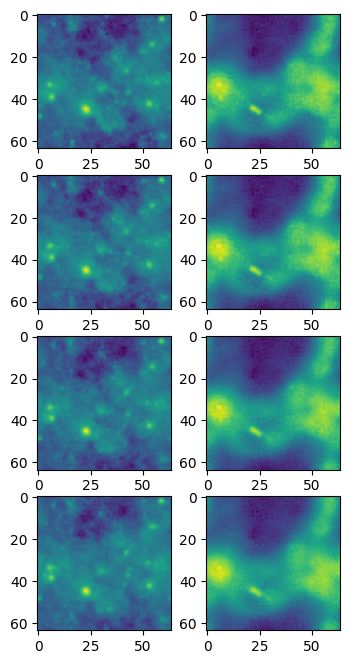

In [122]:
N_res = vcic_paint(jnp.zeros(mesh_shape), res_poss, 1)
res_N = vcic_read(N_res, res_poss)
Ps_res = jax.vmap(cic_paint, in_axes=(None,0,0))(jnp.zeros(mesh_shape), res_poss, res_Ps/res_N)

ref_poss = gas_poss[i_loss]
ref_Ps = gas_Ps[i_loss]
N_ref = vcic_paint(jnp.zeros(mesh_shape), ref_poss, 1)
ref_N = vcic_read(N_ref, ref_poss)
Ps_ref = jax.vmap(cic_paint, in_axes=(None,0,0))(jnp.zeros(mesh_shape), ref_poss, ref_Ps/ref_N)

n_scales = len(ref_t)
fig, ax = plt.subplots(nrows=n_scales, ncols=2, figsize=(4, n_scales*2))

for i in range(n_scales):
    ax[i,0].imshow(Ps_ref[i].sum(axis=0), norm="log")
    ax[i,1].imshow(Ps_res[i].sum(axis=0), norm="log")

In [37]:
stop

NameError: name 'stop' is not defined

### loss evolution

In [ ]:
pos_loss = ParticleLoss(
    mesh_per_dim,
    w_pos=1.0,
    w_vel=0.0,
    w_cls=0.0,
    w_cross=0.0,
    w_snapshot=0.0,
)

In [ ]:
# gas

og_loss = pos_loss(
    og_gas_poss,
    og_gas_vels,
    gas_poss[i_loss],
    gas_vels[i_loss],
    cls_gas[i_loss],
    deltas_gas[i_loss],
    debug=False,
    particle_mean=True,
    snapshot_mean=False,
)

nn_loss = pos_loss(
    nn_gas_poss,
    nn_gas_vels,
    gas_poss[i_loss],
    gas_vels[i_loss],
    cls_gas[i_loss],
    deltas_gas[i_loss],
    debug=False,
    particle_mean=True,
    snapshot_mean=False,
)

fig, ax = plt.subplots()

ax.plot(scales[i_loss], og_loss, label="og")
ax.plot(scales[i_loss], nn_loss, label="nn")

ax.legend()

In [ ]:
# dark matter

og_loss = pos_loss(
    og_dm_poss,
    og_dm_vels,
    dm_poss[i_loss],
    dm_vels[i_loss],
    cls_dm[i_loss],
    deltas_dm[i_loss],
    debug=False,
    particle_mean=True,
    snapshot_mean=False,
)

nn_loss = pos_loss(
    nn_dm_poss,
    nn_dm_vels,
    dm_poss[i_loss],
    dm_vels[i_loss],
    cls_dm[i_loss],
    deltas_dm[i_loss],
    debug=False,
    particle_mean=True,
    snapshot_mean=False,
)

fig, ax = plt.subplots()

ax.plot(scales[i_loss], og_loss, label="og")
ax.plot(scales[i_loss], nn_loss, label="nn")

ax.legend()


### particle displacement

In [ ]:
i_rel = -1
i_abs = i_loss[-1]

og_loss = pos_loss(
    og_gas_poss[i_rel],
    og_gas_vels[i_rel],
    gas_poss[i_abs],
    gas_vels[i_abs],
    cls_gas[i_abs],
    deltas_gas[i_abs],
    debug=False,
    particle_mean=False,
    snapshot_mean=False,
)

nn_loss = pos_loss(
    nn_gas_poss[i_rel],
    nn_gas_vels[i_rel],
    gas_poss[i_abs],
    gas_vels[i_abs],
    cls_gas[i_abs],
    deltas_gas[i_abs],
    debug=False,
    particle_mean=False,
    snapshot_mean=False,
)

In [ ]:
gas_poss.shape

In [ ]:
fig, ax = plt.subplots(figsize=(16, 8), ncols=2, subplot_kw={"projection": "3d"})
alpha = 1.0
cmap = "Purples"

# Compute global color limits
vmin = min(og_loss.min(), nn_loss.min())
vmax = max(og_loss.max(), nn_loss.max())

im0 = ax[0].scatter(
    gas_poss[i_abs, :, 0], gas_poss[i_abs, :, 1], gas_poss[i_abs, :, 2],
    c=og_loss, cmap=cmap, marker="o", alpha=alpha, s=0.01,
    vmin=vmin, vmax=vmax
)
ax[0].set(title="PM (gravity)")

im1 = ax[1].scatter(
    gas_poss[i_abs, :, 0], gas_poss[i_abs, :, 1], gas_poss[i_abs, :, 2],
    c=nn_loss, cmap=cmap, marker="o", alpha=alpha, s=0.01,
    vmin=vmin, vmax=vmax
)
ax[1].set(title="HPM (gravity + pressure)")

fig.colorbar(im1, ax=ax, orientation="horizontal", shrink=0.8, aspect=30)

### Cls and cross spectra weighting

In [ ]:
kbins, res_cls = objectives.vpower_spectrum(deltas_gas)

k = kbins[0]
k_min, k_cutoff = k[0], k[int(0.4*len(k))]
# k_min, k_cutoff = k[0], 2
k_weights = jnp.exp(-(k - k_min)**2 / k_cutoff)

In [ ]:
k

In [ ]:
64*np.pi/25

In [ ]:
k

In [ ]:
k.shape

In [ ]:
k_weights.shape

In [ ]:
fig, ax = plt.subplots()

ax.plot(k, k_weights)
ax.set(xscale="log")

In [ ]:
k

In [ ]:
k_min

In [ ]:
k_cutoff

In [ ]:
kbins[5]

In [ ]:
kbins[1]

In [ ]:
k_weights

In [ ]:
kbins.shape

## LOSS

In [ ]:
nn_ode = hpm.get_hpm_network_ode_fn(
    mesh_per_dim,
    cosmo,
    gravity_model=gravity_model,
    pressure_model=pressure_model,
)

In [ ]:
nn_res = diffeqsolve(
    terms=ODETerm(nn_ode),
    solver=LeapfrogMidpoint(),
    t0=scales[i0],
    t1=scales[i_loss[-1]],
    dt0=dt0,
    y0=(dm_poss[i0], dm_vels[i0], gas_poss[i0], gas_vels[i0]),
    saveat=SaveAt(ts=scales[i_loss]),
    max_steps=1000,
    stepsize_controller=ConstantStepSize(),
)
nn_dm_poss, nn_dm_vels, nn_gas_poss, nn_gas_vels = nn_res.ys[:4]

In [ ]:
res_poss = nn_gas_poss
ref_poss = gas_poss[i_loss]

# pos loss

In [ ]:
dist = ((res_poss - ref_poss + mesh_per_dim // 2) % mesh_per_dim) - mesh_per_dim // 2
pos_loss = jnp.sum(dist**2, axis=-1)
# pos_loss = jnp.sum(huber_loss((res_poss - ref_poss + mesh_per_dim // 2), mesh_per_dim // 2), axis=-1)
pos_loss = np.where(pos_loss < jnp.quantile(pos_loss, 0.9), pos_loss, 0.0)

In [ ]:
fig, ax = plt.subplots()
for i in range(pos_loss.shape[0]):
    current_pos_loss = pos_loss[i]
    ax.hist(current_pos_loss, bins=np.linspace(jnp.quantile(current_pos_loss, 0.01), jnp.quantile(current_pos_loss, 0.99), 100))

In [ ]:
def normalized_paint(positions, weights):
    rho_pos = cic_paint(jnp.zeros([mesh_per_dim] * 3), positions)
    pos_rho = cic_read(rho_pos, positions)

    return cic_paint(jnp.zeros(mesh_shape), positions, weights/pos_rho)

def plot_field(field, ax, vlims=None):
    log_sum = jnp.log10(field.sum(axis=0))

    if vlims is None:
        vmin, vmax = log_sum.min(), log_sum.max()
        vlims = (vmin, vmax)
    else:
        vmin, vmax = vlims

    im = ax.imshow(log_sum, cmap="magma", vmin=vmin, vmax=vmax)
    fig.colorbar(im, ax=ax, orientation="horizontal", shrink=0.6, aspect=10)
    
    return im, vlims, log_sum

In [ ]:
i_ex = -1
gas_pos = gas_poss[i_ex]
loss_ex = pos_loss[i_ex]

rho_gas  = cic_paint(jnp.zeros([mesh_per_dim] * 3), gas_pos)
loss_field = normalized_paint(gas_pos, loss_ex)

In [ ]:
fig = plt.figure(figsize=(8, 8))
ax = fig.add_subplot(111, projection='3d')

im = ax.scatter(gas_pos[:, 0], gas_pos[:, 1], gas_pos[:, 2], c=loss_ex, cmap="viridis", marker="o", alpha=0.3, s=0.01)
fig.colorbar(im, ax=ax, orientation="horizontal", shrink=0.8, aspect=20)

In [ ]:
fig, ax = plt.subplots()
for i in range(pos_loss.shape[0]):
    ax.hist(jnp.log(loss_field.sum(axis=0)).flatten(), bins=100)

In [ ]:
fig, ax = plt.subplots(ncols=2)

im0 = ax[0].imshow(jnp.log(rho_gas.sum(axis=0)))
im1 = ax[1].imshow(jnp.log(loss_field.sum(axis=0)))

fig.colorbar(im0, ax=ax[0], orientation="horizontal", shrink=0.6, aspect=10)
fig.colorbar(im1, ax=ax[1], orientation="horizontal", shrink=0.6, aspect=10)

ax[0].set(title="gas density")
ax[1].set(title="gas displacement loss")

# field loss

In [ ]:
i_ex = -1
res_pos = res_poss[i_ex]
ref_delta = deltas_gas[i_ex]

res_rho = cic_paint(jnp.zeros([mesh_per_dim] * 3), res_pos)
res_delta = res_rho/res_rho.mean() - 1 

field_loss = (res_delta - ref_delta) ** 2

In [ ]:
field_loss.shape

In [ ]:
fig, ax = plt.subplots()

ax.hist(field_loss.flatten(), bins=np.linspace(np.quantile(field_loss, 0.01), np.quantile(field_loss, 0.90), 100));

In [ ]:
fig, ax = plt.subplots(ncols=3)

im0 = ax[0].imshow(jnp.log(ref_rho.sum(axis=0)))
im1 = ax[0].imshow(jnp.log(res_rho.sum(axis=0)))
im2 = ax[1].imshow(jnp.log((field_loss).sum(axis=0)))

fig.colorbar(im0, ax=ax[0], orientation="horizontal", shrink=0.6, aspect=10)
fig.colorbar(im1, ax=ax[1], orientation="horizontal", shrink=0.6, aspect=10)
fig.colorbar(im2, ax=ax[2], orientation="horizontal", shrink=0.6, aspect=10)

ax[0].set(title="rho gas (CAMELS)")
ax[1].set(title="rho gas (HPM)")
ax[2].set(title="rho loss")

In [ ]:
ode = ODETerm(
    hpm.get_hpm_network_ode_fn(
        mesh_per_dim, 
        cosmo, 
        gravity_model=None, 
        pressure_model=pressure_model, 
    )
)

y0 = (dm_poss[i0], dm_vels[i0], gas_poss[i0], gas_vels[i0], jnp.zeros(mesh_shape))
t0 = scales[i0]
ts = scales[i_loss]

res = diffeqsolve(
    terms=ode,
    solver=LeapfrogMidpoint(),
    t0=t0,
    t1=ts[-1],
    dt0=dt0,
    y0=y0,
    saveat=SaveAt(ts=ts),
    max_steps=100,
    stepsize_controller=ConstantStepSize(),
)

In [ ]:
ode

In [ ]:
# y0 = (dm_poss[i0], dm_vels[i0], gas_poss[i0], gas_vels[i0])
y0 = (dm_poss[i0], dm_vels[i0], gas_poss[i0], gas_vels[i0], jnp.zeros(mesh_shape))
t0 = scales[i0]
ts = scales[i_loss]

nn_res = solve_ode(y0, t0, ts, gravity_model, pressure_model)
# nn_dm_poss, nn_dm_vels, nn_gas_poss, nn_gas_vels = nn_res
nn_dm_poss, nn_dm_vels, nn_gas_poss, nn_gas_vels, nn_gas_Ps = nn_res

In [ ]:
kvec = fftk(mesh_shape)

rhos_res = vcic_paint(jnp.zeros(mesh_shape), nn_gas_poss, 1)
res_rhos = vcic_read(rhos_res, nn_gas_poss)

rhos_res_k = jnp.fft.rfftn(rhos_res, axes=(1,2,3))
fscalar_res = jnp.fft.irfftn(rhos_res_k * invnabla_kernel(kvec), axes=(1,2,3))
res_fscalar = vcic_read(res_fscalar_field, nn_gas_poss)

gas_inputs = [
    jnp.tile(ts[:,jnp.newaxis], res_rhos.shape[1]),
    jnp.log10(res_rhos + 1e-8),
    jnp.arcsinh(res_fscalar),
]
gas_inputs = jnp.stack(gas_inputs, axis=-1)

gas_preds = pressure_model(gas_inputs)
gas_P = 10 ** jnp.squeeze(gas_preds)


In [ ]:
gas_P.shape

In [ ]:
gas_preds.shape

In [ ]:
res_rhos.shape

In [ ]:
jnp.arcsinh(res_fscalar).shape

In [ ]:
ts.shape

In [ ]:
jnp.repeat(ts, 10, axis=-1).shape

In [ ]:
temp = jnp.tile(ts[:,jnp.newaxis], 2)

In [ ]:
temp

In [ ]:
temp.shape

In [ ]:
ts[:,jnp.newaxis].shape

In [ ]:
jnp.tile(ts, nn_gas_poss.shape[1], axis=0).shape

In [ ]:
nn_gas_poss.shape

In [ ]:
jnp.log10(res_rhos + 1e-8).shape

In [ ]:
jnp.arcsinh(res_fscalar).shape

In [ ]:
ts

In [ ]:
res_fscalar.shape

In [ ]:
res_fscalar.shape

In [ ]:
res_rhos_k.shape

In [ ]:
res_fscalar.shape

In [ ]:
res_rhos_k.shape